<a href="https://colab.research.google.com/github/SampMark/Machine-Learning/blob/main/Hinge_Loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Risco Empírico e a Função de Perda (_hinge loss_)**


Neste laboratório, iremos explorar o conceito de **risco empírico** e como ele se aplica à avaliação de modelos de aprendizado de máquina, com foco na função de perda Hinge.

O risco empírico é uma medida fundamental para quantificar o desempenho de um modelo em um conjunto de dados de treinamento, permitindo-nos selecionar o modelo que melhor se ajusta aos dados. Por sua vez, a métrica _hinge loss_ é a **"Perda de Margem"** ou "**Perda do classificador"**, num modelo de  classificação linear, sendo por exemplo amplamente utilizada para avaliação de modelos como a **Máquina de Vetores de Suporte** (*Support Vector Machine - SVM*) e outros classificadores lineares.


### **Definição Matemática do Risco Empírico:**

Ao treinarmos um modelo de aprendizado supervisionado, como a regressão linear, dispomos de um conjunto de treinamento com $n$ exemplos conhecidos $(\mathbf{x}_i, y_i)$.

O **Risco Empírico** é o termo que designa o erro médio do modelo medido nesses dados de treinamento – essencialmente, é a própria função de custo calculada sobre o conjunto de treino. Em suma, é definido como a média da perda sobre todos os exemplos de treinamento.

No caso de uma regressão linear com erro quadrático,  o risco empírico $R_{\text{n}}(\boldsymbol{\theta})$ corresponde ao EQM: é calculado somando a perda (erro) em cada exemplo e dividindo pelo número total de exemplos $n$, matematicamente:

$$ R_n (\theta) = \frac{1}{n} \sum_{t=1}^{n} \text{Loss} \left( y^{(t)} - \theta^T \cdot x^{(t)} \right)$$

Onde:
* $n$ é o número total de exemplos de treinamento.
* $Loss_h(z)$ é a função de perda Hinge.
* $(x^{(t)}, y^{(t)})$ é o t-ésimo exemplo de treinamento.
* $\theta^T$ é o vetor de parâmetros dado.

**Função de Perda Hinge:**

A função de perda Hinge é comumente usada em algoritmos de aprendizado de máquina, especialmente em máquinas de vetores de suporte (SVMs), sendo dada por:

$$Loss_h(z)= y^{(t)} - \theta^T \cdot x^{(t)}$$

Ou ainda:

$$
L(y, \hat{y}) = \max(0, 1 - y \cdot (\theta^T x + \theta_0))
$$

onde:
- $ x $ é o **vetor de características** (*feature_vector*).
- $ y $ é o **rótulo verdadeiro** (*label*), que assume valores $ +1 $ ou $ -1 $.
- $ \theta $ é o **vetor de pesos** do classificador.
- $ \theta_0 $ é o **termo de viés** (*bias*).
- $ \theta^T x $ representa o produto escalar entre o vetor de pesos e o vetor de características.

A função retorna **zero** se a predição for suficientemente correta ($ y \cdot (\theta^T x + \theta_0) \geq 1 $), e um valor positivo se a previsão estiver errada ou dentro da margem de decisão.é dada por:

$$
\text{Loss}_h (z) =
\begin{cases}
0, & \text{se } z \geq 1 \\
1 - z, & \text{caso contrário,} \text{ se } z < 1
\end{cases}
$$

Em suma, a função penaliza as classificações erradas ou que estejam dentro da margem de decisão.

**Interpretação da Função de Perda Hinge:**

A função de perda Hinge penaliza as previsões incorretas e também as previsões corretas que estão dentro da margem. O que incentiva o modelo a encontrar uma solução que não apenas classifique os pontos corretamente, mas também os separe com uma margem significativa.

**Considerações Adicionais**

O risco empírico e a função de perda Hinge são conceitos importantes em aprendizado de máquina.

A discussão sobre "Risco Empírico" reforça a importância de se escolher uma função de perda adequada para o problema em questão. A função de perda Hinge é uma escolha conhecida em problemas de classificação, especialmente quando se quer obter uma margem de separação entre as classes, portanto, em suma:

* A escolha da função de perda depende do problema específico e dos objetivos de aprendizado.
* Existem outras funções de perda comuns, como o erro quadrático e a perda logística.
* A regularização pode ser adicionada ao risco empírico para evitar overfitting.

Ao entender o risco empírico, é possível avaliar melhor o desempenho dos modelos e escolher aqueles que generalizam bem para novos dados.

---

In [ ]:
# @title Importando as bibliotecas
import numpy as np

## **Funções _hinge loss_**

---


A função `hinge_loss_single` calcula a margem de perda para um único ponto de dados em um classificador linear `hinge_loss_full`a perda média para um conjunto de dados.


In [ ]:
# Funções de Perda
def hinge_loss(z):
  """
  Calcula a Hinge Loss para um valor z.

  Args:
    z: float ou numpy array.

  Returns:
    float ou numpy array com a Hinge Loss correspondente.
  """
  if isinstance(z, np.ndarray):
      return np.where(z >= 1, 0, 1 - z)
  else: # Para valores escalares
      return 0 if z >= 1 else 1 - z

def squared_error_loss(z):
  """
  Calcula a Squared Error Loss para um valor z.

  Args:
    z: float ou numpy array.

  Returns:
    float ou numpy array com a Squared Error Loss correspondente.
  """
  return z**2 / 2

# Função para calcular o Risco Empírico
def empirical_risk(loss_function, theta, X, Y):
  """
  Calcula o Risco Empírico para uma dada função de perda, parâmetros theta,
  e dados de treinamento (X, Y).

  Args:
    loss_function: Função de perda a ser utilizada (hinge_loss ou squared_error_loss).
    theta: numpy array representando o vetor de parâmetros (theta).
    X: numpy array representando a matriz de dados de entrada (x^(t)).
    Y: numpy array representando o vetor de valores de saída (y^(t)).

  Returns:
    float: O valor do Risco Empírico.
  """
  n = len(Y)
  total_loss = 0
  for t in range(n):
    x_t = X[t]
    y_t = Y[t]
    z_t = y_t - np.dot(theta, x_t) # Calcula y^(t) - theta^T * x^(t)
    loss_t = loss_function(z_t)      # Calcula a perda para o exemplo t
    total_loss += loss_t
  return total_loss / n

In [ ]:
# Dados de treinamento do problema exemplo
X_data = np.array([
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, -1],
    [-1, 1, 1]
])
Y_data = np.array([2, 2.7, -0.7, 2])
theta_data = np.array([0, 1, 2])

# Calcular o Risco Empírico com Hinge Loss
risco_empirico_hinge = empirical_risk(hinge_loss, theta_data, X_data, Y_data)
print(f"Risco Empírico com Hinge Loss: {risco_empirico_hinge:.4f}")

# Calcular o Risco Empírico com Squared Error Loss
risco_empirico_squared_error = empirical_risk(squared_error_loss, theta_data, X_data, Y_data)
print(f"Risco Empírico com Squared Error Loss: {risco_empirico_squared_error:.4f}")

Risco Empírico com Hinge Loss: 1.2500
Risco Empírico com Squared Error Loss: 0.1475


In [ ]:
# @title **Função _hinge loss_ para um único ponto de dados**

def hinge_loss_single(feature_vector: np.ndarray, label: float, theta: np.ndarray, theta_0: float) -> float:
    """
    Calcula a margem de perda (hinge loss) para um único ponto de dados, isto é,
    mede o erro da predição com base em uma margem de decisão.

    Args:
        feature_vector (np.ndarray): Vetor de características do exemplo.
        label (float): Rótulo verdadeiro (+1 ou -1).
        theta (np.ndarray): Vetor de pesos do classificador.
        theta_0 (float): Termo de viés (bias).

    Returns:
        float: Valor do hinge loss.
    """
    # Calcula a margem: y * (theta^T * x + theta_0)
    margin = label * (np.dot(theta, feature_vector) + theta_0)

    # Calcula a perda de dobradiça
    loss = max(0, 1 - margin)

    return float(loss)

In [ ]:
# @title Exemplos de cálculo para função 'hinge_loss_single'

# Exemplo de uso da função hinge_loss_single
feature_vector = np.array([1, 2, 3])  # Vetor de características
label = 1  # Rótulo verdadeiro (+1)
theta = np.array([0.5, 0.2, -0.1])  # Vetor de pesos
theta_0 = 0.3  # Termo de viés

# Calcula a perda de dobradiça
loss = hinge_loss_single(feature_vector, label, theta, theta_0)

# Imprime o resultado
print(f"Hinge Loss: {loss}")

#Outro exemplo
feature_vector = np.array([-1, -2])
label = -1
theta = np.array([1, 1])
theta_0 = 0

loss = hinge_loss_single(feature_vector, label, theta, theta_0)
print(f"Hinge Loss: {loss}")

Hinge Loss: 0.10000000000000009
Hinge Loss: 0.0


In [ ]:
# @title **Função hinge_loss_full para um conjunto de dados**

def hinge_loss_full(feature_matrix: np.ndarray, labels: np.ndarray, theta: np.ndarray, theta_0: float) -> float:
    """
    Calcula o hinge loss médio para um conjunto de dados.
    A função calcula a perda para cada ponto de dados e retorna a média dessas perdas.

    Args:
        feature_matrix (np.ndarray): Matriz onde cada linha representa um ponto de dados.
        labels (np.ndarray): Vetor de rótulos (+1 ou -1), onde cada elemento corresponde à classificação correta da linha correspondente em feature_matrix.
        theta (np.ndarray): Vetor de pesos do classificador.
        theta_0 (float): Termo de deslocamento (bias) do classificador.

    Returns:
        float: Valor da perda de dobradiça média associada ao conjunto de dados e parâmetros fornecidos.
    """
    # Calcula a margem para todos os exemplos de uma vez (vetorização)
    # `np.dot(theta, feature_vector)` calculaa o produto escalar de forma eficiente
    margins = labels * (np.dot(feature_matrix, theta) + theta_0)

    # Calcula a margem de perda média
    losses = np.maximum(0, 1 - margins)

    # Retorna a média das perdas
    return np.mean(losses)

In [ ]:
# @title Exemplos de cálculo para 'hinge_loss_full'

# Exemplo 1:
feature_matrix = np.array([[1, 2], [3, 4], [5, 6]])
labels = np.array([1, -1, 1])
theta = np.array([0.5, -0.2])
theta_0 = 0.1

loss = hinge_loss_full(feature_matrix, labels, theta, theta_0)
print(f"Hinge Loss (Exemplo 1): {loss:4f}")

# Exemplo 2:
feature_matrix = np.array([[-1, -2], [0, 0], [1, 2]])
labels = np.array([-1, 1, -1])
theta = np.array([1, 1])
theta_0 = 0

loss = hinge_loss_full(feature_matrix, labels, theta, theta_0)
print(f"Hinge Loss (Exemplo 2): {loss:4f}")

# Exemplo 3 (com mais dados)
feature_matrix = np.random.rand(100, 2)  # 100 amostras com 2 características
labels = np.random.choice([-1, 1], size=100) # Rótulos aleatórios
theta = np.random.rand(2) # pesos aleatórios
theta_0 = 0.5

loss = hinge_loss_full(feature_matrix, labels, theta, theta_0)
print(f"Hinge Loss (Exemplo 3): {loss:4f}")

Hinge Loss (Exemplo 1): 0.866667
Hinge Loss (Exemplo 2): 1.666667
Hinge Loss (Exemplo 3): 1.192372


In [ ]:
# @title **Função para o cálculo da perda empírica:** $ R_n (\theta) = \frac{1}{n} \sum_{t=1}^{n} \text{Loss} \left( y^{(t)} - \theta \cdot x^{(t)} \right) $

# Funções de Perda
def hinge_loss(z):
  """
  Calcula a Hinge Loss para um valor z.

  Args:
    z: float ou numpy array.

  Returns:
    float ou numpy array com a Hinge Loss correspondente.
  """
  if isinstance(z, np.ndarray):
      return np.where(z >= 1, 0, 1 - z)
  else: # Para valores escalares
      return 0 if z >= 1 else 1 - z

def squared_error_loss(z):
  """
  Calcula a Squared Error Loss para um valor z.

  Args:
    z: float ou numpy array.

  Returns:
    float ou numpy array com a Squared Error Loss correspondente.
  """
  return z**2 / 2

# Função para calcular o Risco Empírico
def empirical_risk(loss_function, theta, X, Y):
  """
  Calcula o Risco Empírico para uma dada função de perda, parâmetros theta,
  e dados de treinamento (X, Y).

  Args:
    loss_function: Função de perda a ser utilizada (hinge_loss ou squared_error_loss).
    theta: numpy array representando o vetor de parâmetros (theta).
    X: numpy array representando a matriz de dados de entrada (x^(t)).
    Y: numpy array representando o vetor de valores de saída (y^(t)).

  Returns:
    float: O valor do Risco Empírico.
  """
  n = len(Y)
  total_loss = 0
  for t in range(n):
    x_t = X[t]
    y_t = Y[t]
    z_t = y_t - np.dot(theta, x_t) # Calcula y^(t) - theta^T * x^(t)
    loss_t = loss_function(z_t)      # Calcula a perda para o exemplo t
    total_loss += loss_t
  return total_loss / n

In [ ]:
# @title Exemplo para cálculo do risco empírico
X_data = np.array([
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, -1],
    [-1, 1, 1]
])
Y_data = np.array([2, 2.7, -0.7, 2])
theta_data = np.array([0, 1, 2])

# Calcular o Risco Empírico com Hinge Loss
risco_empirico_hinge = empirical_risk(hinge_loss, theta_data, X_data, Y_data)
print(f"Risco Empírico com Hinge Loss: {risco_empirico_hinge:.4f}")

# Calcular o Risco Empírico com Squared Error Loss
risco_empirico_squared_error = empirical_risk(squared_error_loss, theta_data, X_data, Y_data)
print(f"Risco Empírico com Squared Error Loss: {risco_empirico_squared_error:.4f}")

Risco Empírico com Hinge Loss: 1.2500
Risco Empírico com Squared Error Loss: 0.1475


In [ ]:
# @title Mais Exemplos de Treinamento


# Exemplo 4:  Testando com um vetor theta diferente
X_data_4 = np.array([
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, -1],
    [-1, 1, 1]
])
Y_data_4 = np.array([2, 2.7, -0.7, 2])
theta_data_4 = np.array([1, 0, 0]) # um vetor de theta diferente para comparação

risco_empirico_hinge_4 = empirical_risk(hinge_loss, theta_data_4, X_data_4, Y_data_4)
print(f"Risco Empírico com Hinge Loss (Exemplo 4): {risco_empirico_hinge_4:.4f}")

# Exemplo 5: Dados com ruído
X_data_5 = np.random.rand(50, 3)
Y_data_5 = np.random.randint(0, 2, 50) * 2 - 1  # Rótulos -1 e 1 com ruído
theta_data_5 = np.random.rand(3)

risco_empirico_hinge_5 = empirical_risk(hinge_loss, theta_data_5, X_data_5, Y_data_5)
print(f"Risco Empírico com Hinge Loss (Exemplo 5): {risco_empirico_hinge_5:.4f}")

# Exemplo 6: Dados com diferentes escalas
X_data_6 = np.array([
    [1, 10, 100],
    [2, 20, 200],
    [3, 30, 300]
])
Y_data_6 = np.array([1, 2, 3])
theta_data_6 = np.array([0.1, 0.01, 0.001])

risco_empirico_hinge_4 = empirical_risk(hinge_loss, theta_data_6, X_data_6, Y_data_6)
print(f"Risco Empírico com Hinge Loss (Exemplo 6): {risco_empirico_hinge_6:.4f}")

#Exemplo 7 - Testando com mais dados:
X_data_7 = np.random.rand(200,5)
Y_data_7 = np.random.randint(0,2,200) *2 -1
theta_data_7 = np.random.rand(5)

risco_empirico_hinge_7 = empirical_risk(hinge_loss, theta_data_7, X_data_7, Y_data_7)
print(f"Risco Empírico com Hinge Loss (Exemplo 7): {risco_empirico_hinge_7:.4f}")

Risco Empírico com Hinge Loss (Exemplo 4): 0.6750
Risco Empírico com Hinge Loss (Exemplo 5): 1.8283
Risco Empírico com Hinge Loss (Exemplo 6): 0.6750
Risco Empírico com Hinge Loss (Exemplo 7): 2.4398


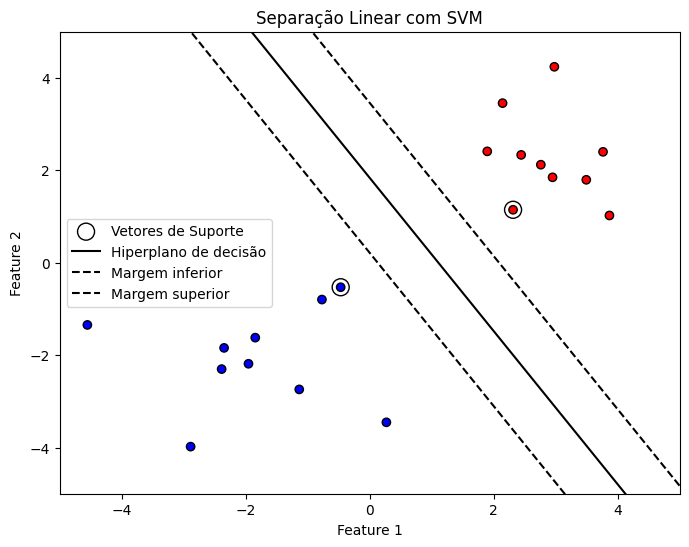

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Gerando dados fictícios
np.random.seed(0)
X1 = np.random.randn(10, 2) + [2, 2]  # Classe +1
X2 = np.random.randn(10, 2) + [-2, -2]  # Classe -1
X = np.vstack((X1, X2))
y = np.hstack((np.ones(10), -np.ones(10)))  # Rótulos +1 e -1

# Criando e treinando o SVM linear
svm = SVC(kernel="linear", C=1)
svm.fit(X, y)

# Obtendo coeficientes do hiperplano
w = svm.coef_[0]  # Vetor de pesos
b = svm.intercept_[0]  # Viés (bias)

# Criando a reta de decisão
xx = np.linspace(-5, 5, 100)
yy = - (w[0] * xx + b) / w[1]

# Obtendo vetores de suporte
support_vectors = svm.support_vectors_

# Plotando os dados
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150,
            facecolors='none', edgecolors='k', label='Vetores de Suporte')

# Desenhando a reta de decisão
plt.plot(xx, yy, 'k-', label="Hiperplano de decisão")

# Criando margens
margin = 1 / np.linalg.norm(w)
yy_down = yy - margin
yy_up = yy + margin

plt.plot(xx, yy_down, 'k--', label="Margem inferior")
plt.plot(xx, yy_up, 'k--', label="Margem superior")

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.title("Separação Linear com SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
